<a href="https://colab.research.google.com/github/MarioD0m/ProfessionalPortfolio/blob/main/Predictive_Maintenance_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Maintenance Pipeline for CNC machine Project

## Data Upload and Exploration

### Libraries and file upload

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Pandas and Numpy will be used for EDA, and for the purpose of confort, Google Drive will be used to store and upload the file.

In [67]:
df = pd.read_csv('/content/drive/MyDrive/Portfolio_projects/Predictive_Maintenance/ai4i2020.csv')
display(df.head())

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Exploratory data analysis

### Dataset description

The **AI4I 2020 Predictive Maintenance Dataset** from **the UCI Machine Learning Repository** was selected as the data source, to ensure statistical validity and a robust volume of data. This is a highly respected, synthetic dataset explicitly designed to reflect real-world predictive maintenance telemetry encountered in modern industry.

Dataset Characteristics:
* Size: 10,000 instances (representing machine operational cycles).
* Features: 14 highly specific engineering variables.
* Key Predictors:
* * Type: Product quality variants (Low, Medium, High).
* * Air temperature [K] & Process temperature [K]
* * Rotational speed [rpm] & Torque [Nm]
* * Tool wear [min]

Target Variables:
* Machine failure (Binary)
* Specific failure modes like TWF (Tool Wear Failure) and HDF (Heat Dissipation Failure)



The dataset consists of 10 000 data points stored as rows with 14 features in columns:

*  **UID (*integer*):** unique identifier ranging from 1 to 10000 (index).
* **product ID (*categorical*):** consisting of a letter L, M, or H for low (50% of all products), medium (30%) and high (20%) as product quality variants and a variant-specific serial number.
* **type (*categorical*):** consisting of the letters L, M or H, which indicates the product quality type (correlated with product ID).
* **air temperature [K] (*continuous*):** generated using a random walk process later normalized to a standard deviation of 2 K around 300 K.
* **process temperature [K] (*continuous*):** generated using a random walk process normalized to a standard deviation of 1 K, added to the air temperature plus 10 K.
* **rotational speed [rpm] (*integer*):** calculated from a power of 2860 W, overlaid with a normally distributed noise.
* **torque [Nm] (*continuous*):** torque values are normally distributed around 40 Nm with a Ïƒ = 10 Nm and no negative values.
* **tool wear [min] (*integer*):** The quality variants H/M/L add 5/3/2 minutes of tool wear to the used tool in the process.
* **'machine failure' label (*integer*):** indicates whether the machine has failed in this particular datapoint for any of the following failure modes are true. If at least one of the above failure modes is true, the process fails and the 'machine failure' label is set to 1.
* **tool wear failure (TWF) (*integer*):** the tool will be replaced of fail at a randomly selected tool wear time between 200 and 240 mins.
* **heat dissipation failure (HDF) (*integer*):** heat dissipation causes a process failure, if the difference between air and process temperature is below 8.6 K and the tools rotational speed is below 1380 rpm.
* **power failure (PWF) (*integer*):** the product of torque and rotational speed (in rad/s) equals the power required for the process. If this power is below 3500 W or above 9000 W, the process fails.
* **overstrain failure (OSF) (*integer*)**: if the product of tool wear and torque exceeds 11,000 minNm for the L product variant (12,000 M, 13,000 H), the process fails due to overstrain.
*  **random failures (RNF) (*integer*):** each process has a chance of 0,1 % to fail regardless of its process parameters.

In [68]:
df.rename(columns={'Product ID':'machine_id','Type':'quality','Air temperature [K]':'air_temp_K','Process temperature [K]':'proc_temp_K','Rotational speed [rpm]':'rot_speed_rpm','Torque [Nm]':'torq_Nm','Tool wear [min]':'tool_wear_min','Machine failure':'machine_failure'}, inplace=True)
df.describe(include='all')

,UDI,machine_id,quality,air_temp_K,proc_temp_K,rot_speed_rpm,torq_Nm,tool_wear_min,machine_failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
unique,NaN,10000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,L57163,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,NaN,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,NaN,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,NaN,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,NaN,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,NaN,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,NaN,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   UDI              10000 non-null  int64  
 1   machine_id       10000 non-null  object 
 2   quality          10000 non-null  object 
 3   air_temp_K       10000 non-null  float64
 4   proc_temp_K      10000 non-null  float64
 5   rot_speed_rpm    10000 non-null  int64  
 6   torq_Nm          10000 non-null  float64
 7   tool_wear_min    10000 non-null  int64  
 8   machine_failure  10000 non-null  int64  
 9   TWF              10000 non-null  int64  
 10  HDF              10000 non-null  int64  
 11  PWF              10000 non-null  int64  
 12  OSF              10000 non-null  int64  
 13  RNF              10000 non-null  int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 1.1+ MB


All the columns match the defined type. There are no null values in the dataset.

The label columns only contain the desired values (0 and 1).

The values of the integer and continuous columns are consistent with the expected data:
* The rotational speed between 1200 and 2400 are normal for the machining of harder materials (like steel), so the min and max values of 1538 and 2886 rpms are within expected values.
* The temperature of air and process in K are within logical values, 295 to 304 K for the air (28-31°C) and 305 to 314 K (32-40°C).
* Values of torque between 30 and 80 are considered normal for machining processes in steel, so values of 3.8 to 77 Nm are within range of the expected values.
* Standard CNC tool wear time typically ranges from 15 to 60 minutes, however 200-240 mins are considered as the threshold for the safety margin, so values betweeen 4 and 260 are within expected values of wear.

### Visualizations

In [70]:
df_eda = df.copy()
df_eda.drop(columns=['UDI', 'machine_id'], inplace=True)
df_eda

,quality,air_temp_K,proc_temp_K,rot_speed_rpm,torq_Nm,tool_wear_min,machine_failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


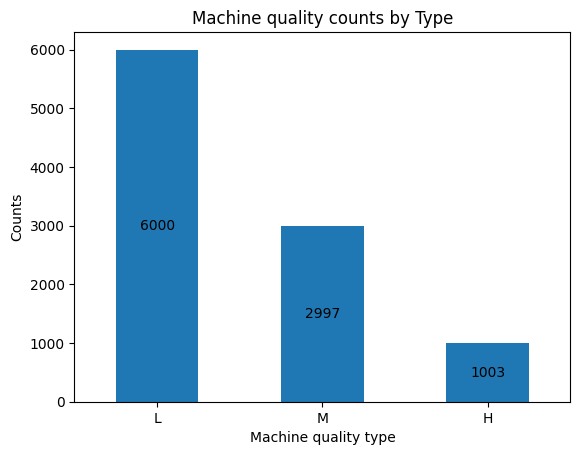

In [71]:
bar_qual=df_eda['quality'].value_counts().plot(kind='bar', legend=False, rot=0)
bar_qual.bar_label(bar_qual.containers[0], label_type='center')
bar_qual.set_title('Machine quality counts by Type')
bar_qual.set_ylabel('Counts')
bar_qual.set_xlabel('Machine quality type')
plt.show()

The Low quality label represent 60% of the dataset, meanwhile Medium and Low 30% and 10% respectively.

In [72]:
df_labels = df_eda[['TWF','HDF','PWF','OSF','RNF']]
counts_set,n_oc,oc = [],[],[]
[counts_set.append(df_labels[counts].value_counts()) for counts in df_labels.columns]
for value, count in counts_set:
  n_oc.append(value)
  oc.append(count)
label_counts = pd.DataFrame(zip(n_oc,oc),index=df_labels.columns.tolist(),columns=['Non-Failure','Failure'])
print('Failure label counts by state (0: failure non-occurrence, 1: failure occurrence)')
display(label_counts)

Failure label counts by state (0: failure non-occurrence, 1: failure occurrence)


,Non-Failure,Failure
TWF,9954,46
HDF,9885,115
PWF,9905,95
OSF,9902,98
RNF,9981,19


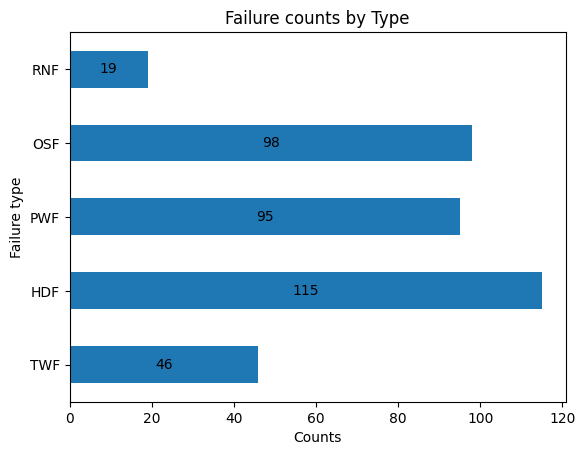

In [73]:
bar_lab = label_counts['Failure'].plot(kind='barh', legend=False, rot=0)
bar_lab.bar_label(bar_lab.containers[0], label_type='center')
bar_lab.set_title('Failure counts by Type')
bar_lab.set_ylabel('Failure type')
bar_lab.set_xlabel('Counts')
plt.show()

The number of failures by each type is displayed above, having heat dissipation failure (HDF) as the most prominent one. On the other hand, random failures (RNF) is the least prominent occurrence.

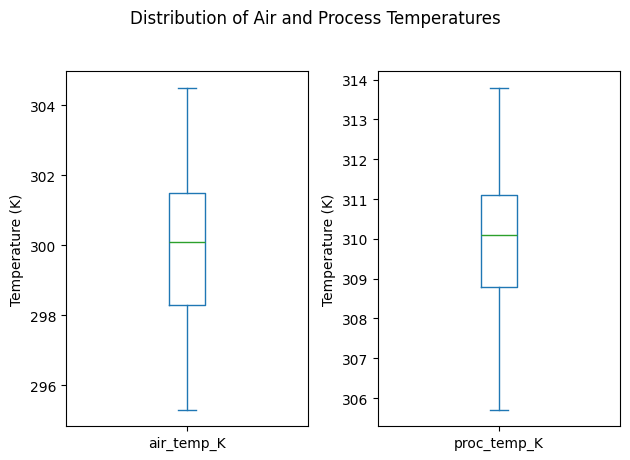

In [74]:
df_temps = df_eda[['air_temp_K','proc_temp_K']]
box_temps = df_temps.plot(kind='box', subplots=True, layout=(1,2), sharex=False, sharey=False)
plt.suptitle('Distribution of Air and Process Temperatures')
box_temps['air_temp_K'].set_ylabel('Temperature (K)')
box_temps['proc_temp_K'].set_ylabel('Temperature (K)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

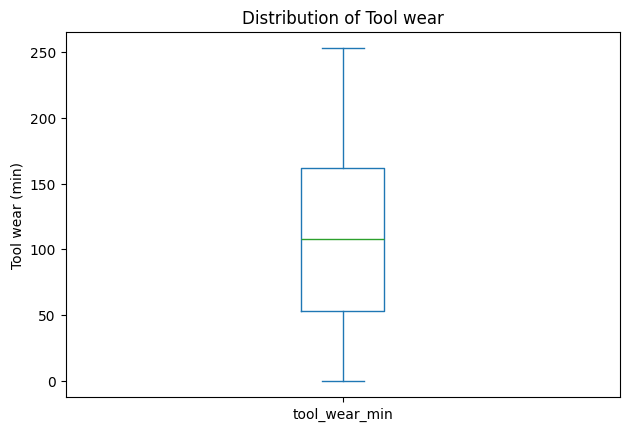

In [75]:
df_wear = df_eda['tool_wear_min']
box_wear = df_wear.plot(kind='box', subplots=True, sharex=False, sharey=False)
plt.title('Distribution of Tool wear')
box_wear['tool_wear_min'].set_ylabel('Tool wear (min)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

No outliers can be identified in the box plots from air and process temperatures, and tool wear, which indicates that all the values are within the expected range.

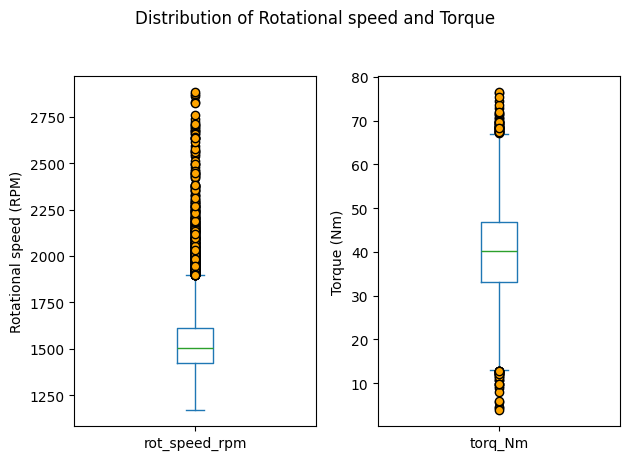

Outliers -> Rotational speed Q3: 1612.0, Torque Q1: 33.2 and Q3: 46.8


In [76]:
df_rot_tor = df_eda[['rot_speed_rpm','torq_Nm']]
outlier = dict(markerfacecolor='orange', marker='o', markeredgecolor='black')
box_rot_tor = df_rot_tor.plot(kind='box', subplots=True, layout=(1,2), sharex=False, sharey=False,flierprops=outlier)
plt.suptitle('Distribution of Rotational speed and Torque')
box_rot_tor['rot_speed_rpm'].set_ylabel('Rotational speed (RPM)')
box_rot_tor['torq_Nm'].set_ylabel('Torque (Nm)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

desc_rot = df_rot_tor['rot_speed_rpm'].describe()
desc_tor = df_rot_tor['torq_Nm'].describe()
q3_rot,q1_tor,q3_tor = desc_rot['75%'],desc_tor['25%'],desc_tor['75%']

plt.show()

print(f'Outliers -> Rotational speed Q3: {q3_rot}, Torque Q1: {q1_tor} and Q3: {q3_tor}')


In [77]:
rot_outliers = df_rot_tor['rot_speed_rpm'] > q3_rot
rot_out_val = rot_outliers.value_counts()

tor_outliers_boolean_series = (df_rot_tor['torq_Nm'] < q1_tor) | (df_rot_tor['torq_Nm'] > q3_tor)
tor_out_val = tor_outliers_boolean_series.value_counts()

print(f'Number of outliers for Rotational speed: {rot_out_val.get(True,0)}')
print(f'Number of outliers for Torque: {tor_out_val.get(True,0)}')

Number of outliers for Rotational speed: 2490
Number of outliers for Torque: 4958


The boxplots of both Rotational speed and Torque, displayed outlier, the former above 1612 RPM, and the latter, presented outliers on both ends, below 33.2 Nm and above 46.8 Nm.

These results showed that both features does not follow a normal distribution, which could indicate that the machine operate under different conditions, where there could exist a "nominal" state, and moments of maximum acceleration without load.

Even if there is a significant quantity of outliers, as previously commented, the values are within expected values under normal operation, so it is nor necessary to purge them from the analysis.

## Feature Enginnering

In [78]:
df.insert(loc=4, column='temp_diff_K', value=df['proc_temp_K'] - df['air_temp_K'])

In [79]:
display(df)

,UDI,machine_id,quality,air_temp_K,temp_diff_K,proc_temp_K,rot_speed_rpm,torq_Nm,tool_wear_min,machine_failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,10.5,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,10.5,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,10.4,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,10.4,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,10.5,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,9.6,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,9.5,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,9.6,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,9.7,308.7,1408,48.5,25,0,0,0,0,0,0


A new feature is created, **Temperature Difference (temp_diff_K)** , which is the difference between Air and Process temperatures, both in Kelvin, resulting in the Thermodynamic stress, in Kelvins, which represent the difference between environmental conditions (ambient air temperature) and the internal temperature of the process.

## Data Wrangling Pipeline

In [80]:
import pandas as pd
import numpy as np
#This pipeline select Google Drive as the file repository
from google.colab import drive
drive.mount('/content/drive')

def data_pipeline (file_path):
  #Execute the ETL Extraction and Transformation phases for the telemetry data
  print("Data pipeline started...")

  #Extraction
  df = pd.read_csv(file_path)
  print(f'File loaded. {df.shape[0]} rows and {df.shape[1]} columns.')

  #Standarization

  #Remove special characters, spaces and convert to lower case
  df.columns = df.columns.str.replace(r'\[|\]', '', regex=True)
  df.columns = df.columns.str.replace(' ', '_')
  df.columns = df.columns.str.lower()

  #Rename key features
  df.rename(columns={'product_id':'machine_id', 'type':'machine_type'}, inplace=True)

  #Handle missing values directly on df to avoid SettingWithCopyWarning
  df_numeric = ['air_temperature_k','process_temperature_k','rotational_speed_rpm','torque_nm','tool_wear_min']
  for col in df_numeric:
    df[col] = df[col].fillna(df[col].mean())

  #Outlier detection using IQR
  for col in df_numeric:
    q1,q3 = df[col].quantile([0.25,0.75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1
    df[f'{col}_outlier'] = np.where((df[col] < lower_bound) | (df[col] > upper_bound),1,0)

  #Feature engineering
  #Create the thermodynamic stress (temp_diff_k) feature
  df.insert(loc=5, column='temp_difference_k', value=df['process_temperature_k'] - df['air_temperature_k'])

  #Cast type feature as categorical type
  df['machine_type'] = df['machine_type'].astype('category')

  return df

#Pipeline execution
#Upload from the working Google Drive folder
file_path = '/content/drive/MyDrive/Portfolio_projects/Predictive_Maintenance/'
upload_file_name = str(input('Enter the name of the file: '))
cnc_df = data_pipeline(f'{file_path}{upload_file_name}.csv')

print('\n Data pipeline finished.')
display(cnc_df.head())
d_types = pd.DataFrame(cnc_df.dtypes)
print('\n Feature types.')
display(d_types.transpose())
#Export csv file to the working Google Drive folder
save_file_name = str(input('Enter the name of the file: '))
cnc_df.to_csv(f'{file_path}{save_file_name}.csv', index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Enter the name of the file: ai4i2020
Data pipeline started...
File loaded. 10000 rows and 14 columns.

 Data pipeline finished.


,udi,machine_id,machine_type,air_temperature_k,process_temperature_k,temp_difference_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,air_temperature_k_outlier,process_temperature_k_outlier,rotational_speed_rpm_outlier,torque_nm_outlier,tool_wear_min_outlier
0,1,M14860,M,298.1,308.6,10.5,1551,42.8,0,0,0,0,0,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,10.5,1408,46.3,3,0,0,0,0,0,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,10.4,1498,49.4,5,0,0,0,0,0,0,0,0,0,1,0
3,4,L47183,L,298.2,308.6,10.4,1433,39.5,7,0,0,0,0,0,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,10.5,1408,40.0,9,0,0,0,0,0,0,0,0,0,0,0



 Feature types.


,udi,machine_id,machine_type,air_temperature_k,process_temperature_k,temp_difference_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,air_temperature_k_outlier,process_temperature_k_outlier,rotational_speed_rpm_outlier,torque_nm_outlier,tool_wear_min_outlier
0,int64,object,category,float64,float64,float64,int64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64


Enter the name of the file: telemetry_db


## Machine Learning Pipeline

### Algorithm selection

For predicting CNC machine failures in a industry setting, we are dealing with a Binary Classification problem (0 = Normal Operation, 1 = Failure).

For this project, the XGBoost (Extreme Gradient Boosting) model was selected, due to the fact that sensor telemetry often has highly non-linear relationships, such as the combination of high torque and low rotational speed causing a failure, but not independently; and the fact that the XGBoost model is exceptional at capturing these non-linear boundaries, and being highly robust to extreme operational outliers, such as the ones observed in the Rotational speed and Torque features.

### Evaluation metrics

In manufacturing, machine failure is rare, as scheduled preventive maintenance are made, however, said maintenance is done whether is needed or not.

Considering that the industry standard for error is around **1-3%**, a simple model that predicts **no failure**, even if its wrong, every single time will achieve a **99-97% accuracy**, which is within industry standard margins, and will be taken as a major win for every Manager.

So, as accuracy does not really provide the optimal solution, **$F_1$-score** is selected as the core metric, which is the harmonic mean of Precision and Recall.

Precision is a measure of how often the model predict an actual failure, which in turn, minimizes false positives. Recall (sensitivity) measure how many machine failures were detected correctly, which minimize the false negatives. The $F_1$-score balances both precision and recall for imbalanced datasets:
$$F_1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

### Hyperparameter Optimization

As the model depends on features derived from sensors under working conditions, in order to balance the model's ability to capture the complex sensor relationships (to avoid underfittings) against its tendency to memorize the training data (to avoid overfitting), a hyperparameter optimizations is required, using GridSearchCV conbined with Cross-Validation ($k$-folds).

Instead of creating a simple train/test split, the optimization will partition the training data into $k$ subsets, in order to train the model under several combinations of parameters, which will result in a comparisson of the different combinations to obtain the optimal parameters for the model which maximizes the $F_1$-score.

### Hyperparameters tuning and model training

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Machine learning model started...
Calculated scale_pos_weight for class imbalance: 27.78

Initiating Grid Search with 5-Fold Cross Validation...
Optimizing strictly for the F1-Score.
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Optimal Hyperparameters:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}

 Final Tuned Model Evaluation
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1939
           1       0.66      0.80      0.73        61

    accuracy                           0.98      2000
   macro avg       0.83      0.90      0.86      2000
weighted avg       0.98      0.98      0.98      2000



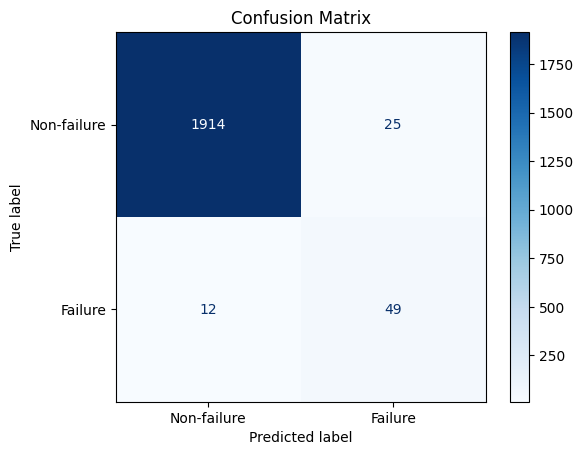


Top 3 Predictive Features:
                Feature  Importance
3  rotational_speed_rpm    0.311677
4             torque_nm    0.295890
5         tool_wear_min    0.218070


In [81]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier
#This pipeline select Google Drive as the file repository
from google.colab import drive
drive.mount('/content/drive')

def pred_maintenance_model(file_path):
  #Loads engineered features from a csv file from Google Drive, perform hyperparameter tuning
  # via GridSearchCV, and train an optimized XGBClassifier model to predict machine failure

  print("Machine learning model started...")
  df = pd.read_csv(file_path)

  #Prepare X and Y features to train the model
  X = df[['air_temperature_k','process_temperature_k','temp_difference_k',
          'rotational_speed_rpm','torque_nm','tool_wear_min']]
  y = df['machine_failure']

  #Train/Test split (80/20)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  weight = (len(y_train) - sum(y_train)) / sum(y_train)
  print(f'Calculated scale_pos_weight for class imbalance: {weight:.2f}')

  #Hyperparameter grid
  param_grid = {
      'max_depth': [3, 5, 7],
      'learning_rate': [0.01, 0.1, 0.2],
      'n_estimators': [100, 200],
      'subsample': [0.8, 1.0]
  }

  #Base Model and Grid Search
  print("\nInitiating Grid Search with 5-Fold Cross Validation...")
  print("Optimizing strictly for the F1-Score.")

  base_xgb = XGBClassifier(
        scale_pos_weight=weight,
        random_state=42,
        eval_metric='logloss')

  #Use F1 scoring to determine the best model
  f1_scorer = make_scorer(f1_score)

  grid_search = GridSearchCV(
        estimator=base_xgb,
        param_grid=param_grid,
        scoring=f1_scorer,
        cv=5,
        n_jobs=-1,
        verbose=1)

  #Fit the Grid Search
  grid_search.fit(X_train, y_train)

  #Extract Best Model and Evaluate
  best_model = grid_search.best_estimator_
  print(f"\nOptimal Hyperparameters:\n{grid_search.best_params_}")

  # Final Predictions on the unseen test set
  y_pred = best_model.predict(X_test)

  print("\n Final Tuned Model Evaluation")
  print(classification_report(y_test, y_pred))

  #Confusion matrix display
  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Non-failure', 'Failure'])
  disp.plot(cmap=plt.cm.Blues)
  plt.title('Confusion Matrix')
  plt.show()

  #Feature Importance Extraction
  importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
  }).sort_values(by='Importance', ascending=False)

  print("\nTop 3 Predictive Features:")
  print(importance_df.head(3))

  return best_model

#Pipeline execution
#Upload from the working Google Drive folder
file_path = '/content/drive/MyDrive/Portfolio_projects/Predictive_Maintenance/'
#upload_file_name = str(input('Enter the name of the file: '))
upload_file_name = 'telemetry_db'
model_df = pred_maintenance_model(f'{file_path}{upload_file_name}.csv')

### Machine learning results analysis

1. Hyperparameters optimization

  | learning_rate| max_depth | n_estimators | subsample |
  |---|---|---|---|
  | 0.1 | 7 | 100 | 0.8 |

  A **max estimator** of 7 indicates the model needed to build relatively deep decision trees to fully capture the complex, non-linear relationships between the sensors. The **subsample** of 0.8 means each tree only looked at 80% of the data, which successfully prevented the model from overfitting. The best **learning_rate** value of 0.1, being small, indicates a highly robust model and less prone to overfitting, but increase the **number of estimators** to increase accuracy, which resulted in 100 estimators.


2. Model evaluation

  | Precision | Recall | $F_1$-score | Accuracy | Flagged cases | Total cases |
  | --- | --- | --- | --- | --- | --- |
  | 66% | 80% | 73% | 98% | 61 | 2000 |

  As expected, the overall accuracy is 98% for the 2000 cases analyzed, where 61 were flagged as failures. With a simple model, a 96.95% of the cases could be correctly flagged as non failures, so the accuracy obtain by this model is greater by a small but significant margin.

  As mentioned before, the selected metric for this project was the **$F_1$-score**, which depend on **Precision** and **Recal**. A Precision of  means that for every 3 alarms raised, 2 were correctly flagged, and do not require maintenance, which, in itself, it's not a bad alocation of resources, being cheaper to make a quick check than a machine.  As the **scale_pos_weight** was applied, **false negatives** are heavily penalized, causing the model to behave overly cautious.
  
  The obtained value for Recall was of 0.8, which means that of the failure cases, 80% of them were correctly idendified. Finally, the value of 73% for the $F_1$-score validates that the model successfully balanced the trade-off between being cautious (Precision) and being comprehensive (Recall) on a highly imbalanced dataset.

3. Confusion matrix

  | True positives | True negatives | False positives | False negatives |
  | --- | --- | --- | --- |
  | 49 | 1914 | 25 | 12 |

  From the confusion matrix, we can observe that from the 2000 test cases, 1914 were flagged as normal operation **(True positives)**. The machine was operating perfectly, and the model correctly left it alone. This represents the vast majority of the operational time, which is exactly what we expect in a healthy manufacturing plant.

  There were 49 instances **(False positives)** where a CNC machine was on the verge of a crash due to excessive torque or tool wear, the model successfully threw a red flag, allowing the maintenance team to intervene. This is were the model really shines, catching correctly possible machine failures.

  The model identified 25 cases as failures **(False positives)**, as it saw a spike in temperature or RPM and triggered an alert, but the machine was actually fine, which causes a maintenance check. While this costs a small amount of labor time, it is an acceptable operational safety buffer.

  Finally, 12 instances were missed **(False negatives)**, where a machine crashed, and the model completely missed the warning signs, which results in a halt in production. This is were the model could be further improved, however, it is important to note that this instances represent 0.6% of the analyzed cases, way below the error margin, nearing a 4-$\sigma$ quality for the production, which is considered good and above average.

### Model evaluation with test cases


 Test cases (new data):


,machine_id,air_temperature_k,process_temperature_k,temp_difference_k,rotational_speed_rpm,torque_nm,tool_wear_min
0,CNC_001,298.1,308.6,10.5,1540,42.5,45
1,CNC_002,298.2,308.7,10.5,1565,41.2,12
2,CNC_003,292.9,308.5,15.6,2542,58.1,199
3,CNC_004,298.5,309.1,10.6,1600,39.5,85
4,CNC_005,299.1,310.2,11.1,1180,68.5,225
5,CNC_006,297.5,308.2,10.7,1555,42.0,55
6,CNC_007,298.0,308.5,10.5,1570,41.5,30
7,CNC_008,298.1,308.6,10.5,1545,42.8,140
8,CNC_009,298.4,308.8,10.4,1580,40.2,95
9,CNC_010,297.8,308.4,10.6,1560,41.8,60



Failure prediction

 RESULTS REPORT FOR FAILURE FLAGGING WITH WORKING CONDITIONS


,machine_id,rotational_speed_rpm,torque_nm,tool_wear_min,failure_probability,test,status
0,CNC_001,1540,42.5,45,0.028000,✅,Normal operation
1,CNC_002,1565,41.2,12,0.020000,✅,Normal operation
2,CNC_003,2542,58.1,199,47.491001,✅,Normal operation
3,CNC_004,1600,39.5,85,0.042000,✅,Normal operation
4,CNC_005,1180,68.5,225,99.874001,🚨,Failure
5,CNC_006,1555,42.0,55,0.028000,✅,Normal operation
6,CNC_007,1570,41.5,30,0.026000,✅,Normal operation
7,CNC_008,1545,42.8,140,0.030000,✅,Normal operation
8,CNC_009,1580,40.2,95,0.038000,✅,Normal operation
9,CNC_010,1560,41.8,60,0.039000,✅,Normal operation



 
 RESULTS REPORT FOR MACHINES FLAGGED AS HAVING A POSSIBLE FAILURE CONDITION


,machine_id,rotational_speed_rpm,torque_nm,tool_wear_min,failure_probability,test,status
2,CNC_003,2542,58.1,199,47.491001,✅,Normal operation
4,CNC_005,1180,68.5,225,99.874001,🚨,Failure
11,CNC_012,1350,58.2,205,98.413002,🚨,Failure
17,CNC_018,1100,72.1,190,99.766998,🚨,Failure
19,CNC_020,1555,69.2,10,99.264999,🚨,Failure



 Line plots of machine with failure conditions


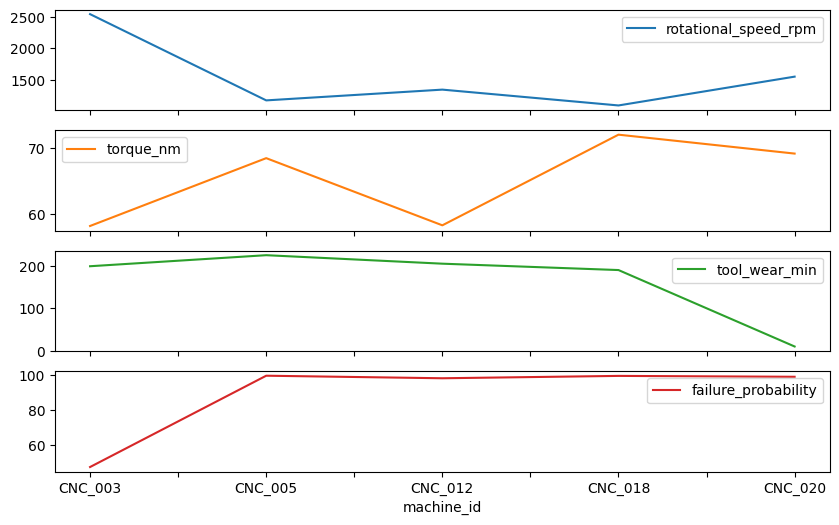

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def simulate_and_score_new_data(model):
    #Test 3 cases to evaluate the model's ability to flag the desired case correctly
    #The cases are composed by synthetic data simulating 3 machine work conditions

    new_data = pd.DataFrame({
        'machine_id': [
            'CNC_001', 'CNC_002', 'CNC_003', 'CNC_004', 'CNC_005',
            'CNC_006', 'CNC_007', 'CNC_008', 'CNC_009', 'CNC_010',
            'CNC_011', 'CNC_012', 'CNC_013', 'CNC_014', 'CNC_015',
            'CNC_016', 'CNC_017', 'CNC_018', 'CNC_019', 'CNC_020'
        ],
        'air_temperature_k': [
            298.1, 298.2, 292.9, 298.5, 299.1,
            297.5, 298.0, 298.1, 298.4, 297.8,
            298.2, 303.5, 298.0, 297.9, 298.1,
            298.3, 298.1, 298.5, 298.2, 298.0
        ],
        'process_temperature_k': [
            308.6, 308.7, 308.5, 309.1, 310.2,
            308.2, 308.5, 308.6, 308.8, 308.4,
            308.7, 314.1, 308.5, 308.4, 308.6,
            308.9, 308.5, 309.2, 308.8, 308.5
        ],
        'rotational_speed_rpm': [
            1540, 1565, 2542, 1600, 1180,
            1555, 1570, 1545, 1580, 1560,
            1550, 1350, 1565, 1555, 1540,
            1575, 1550, 1100, 1560, 1555
        ],
        'torque_nm': [
            42.5, 41.2, 58.1, 39.5, 68.5,
            42.0, 41.5, 42.8, 40.2, 41.8,
            42.4, 58.2, 41.9, 42.1, 43.0,
            40.5, 42.2, 72.1, 41.6, 69.2
        ],
        'tool_wear_min': [
            45, 12, 199, 85, 225,
            55, 30, 140, 95, 60,
            75, 205, 15, 40, 125,
            80, 50, 190, 20, 10
        ]
    })

    #Calculate thermodynamic stress
    new_data.insert(loc=3, column='temp_difference_k',
                    value=new_data['process_temperature_k'] - new_data['air_temperature_k'])

    #Display the data
    print("\n Test cases (new data):")
    display(new_data)

    #Drop categorical column for analysis
    X_new = new_data.copy().drop(columns=['machine_id'])

    #Predict Class and Probability using model
    print("\nFailure prediction")
    predictions = model.predict(X_new)
    probabilities = model.predict_proba(X_new)[:, 1]
    #Keep just the failure probability

    #Create new features for failure flagging and failure probability
    new_data['predicted_failure_flag'] = predictions
    new_data['failure_probability'] = np.round(probabilities * 100, 3)

    results = new_data[['machine_id', 'rotational_speed_rpm','torque_nm','tool_wear_min', 'failure_probability']]

    test_flag, operation_status = [], []

    #Report results
    print("\n RESULTS REPORT FOR FAILURE FLAGGING WITH WORKING CONDITIONS")
    for index, row in new_data.iterrows():
        if row['predicted_failure_flag'] == 1:
            test_flag.append("🚨")
            operation_status.append("Failure")
        else:
            test_flag.append("✅")
            operation_status.append("Normal operation")

    #Insert new features to represent test cases
    results.insert(loc=5, column='test',value=test_flag)
    results.insert(loc=6, column='status',value=operation_status)
    display(results)

    #Display the machines that present a Failure status
    print("\n \n RESULTS REPORT FOR MACHINES FLAGGED AS HAVING A POSSIBLE FAILURE CONDITION")
    flagged_machines = results[(results['status'] == 'Failure') | (results['failure_probability'] > 40)]
    display(flagged_machines)

    #Display line graphs
    print ('\n Line plots of machine with failure conditions')
    flagged_machines.plot(kind='line', x='machine_id', figsize = (10,6), subplots = True)
    plt.show()

    #results_mean = results.copy().drop(columns=['machine_id','test','status','failure_probability'])
    #display(results_mean.mean())

    return new_data

scored_data = simulate_and_score_new_data(model_df)


From the resulting table, we can observe that 4 machines were flagged (CNC_005, CNC_012, CNC_018 and CNC_020) with a failure status, indicating that those machines presented failure conditions. The first 3 machines presented similar working conditions, with rotational speeds below the mean (1556.850 RPM), also, they have similar tool wear (around 200 mins), which is far gratear than the mean (87.35 min), and lastly, the torque is significantly above the mean (47.565 Nm).

Altought CNC_020 present high torque, the rotational speed is around the mean and the tool wear is under 10 min, which could indicate that the combination of a high torque and low to mid rotational speed, could be standard failure condition, independently of the tool wear. This is back by the fact that those feature represent more than 60% of the weight for the prediction. However, this case could be a false positive, where the instance is flagged but the machine does not present failure conditions.

There is also a machine that, although it does not present a failure status, the probability for failure is 47.5%, which presents high torque, high tool wear but shows a high rotational speed. This could be a case were the failure condition is not detected, generating a false negative.